# Лабораторная работа №4
# Правильный многоугольник Рело. Векторизация вычислений в numpy

*Коровацкий Александр Сергеевич, 30.03.2025*

## Задание 4.1. Построение треугольника Рело

Постройте представоение границы правильного треугольника Рело в виде матрицы,
каждая строка которой содержит координаты точек, описывающих границу.
Полагаем, что заданы координаты центра правильного треугольника Рело center ,
ширина треугольника Рело r и количество точек для описания одной стороны
треугольника Рело N .


## Выполнение задания 4.1

Подключим модули

In [7]:
import numpy as np
import matplotlib.pyplot as plt

Определим переменные

In [9]:
n = 3
center = np.array([0,0])
r, N = 10., 100

### Этап 1. Вычисление координат вершин правильного треугольника

Вершины правильного многоугольника расположены на окружности, описанной вокруг многоугольника. Радиус $R$ окружности, описанной вокруг правильного $n$-угольника с длиной стороны $l$, вычисляется по формуле (1):

$$R = \frac{l}{2sin(\frac{\pi}{n})}$$

Длина стороны $l$ правильного треугольника, на котором будем строить треугольник Рело, совпадает с шириной треугольника Рело $r$.

In [12]:
l = r

Вычислим радиус описанной окружности R

In [14]:
R = l / (2 * np.sin(np.pi / n))

In [15]:
t = np.arange(0, 2 * np.pi, 2 * np.pi / n)

vertices = center + R * np.transpose([np.cos(t), np.sin(t)])
vertices

array([[ 5.77350269,  0.        ],
       [-2.88675135,  5.        ],
       [-2.88675135, -5.        ]])

Построим изображение вершин треугольника:

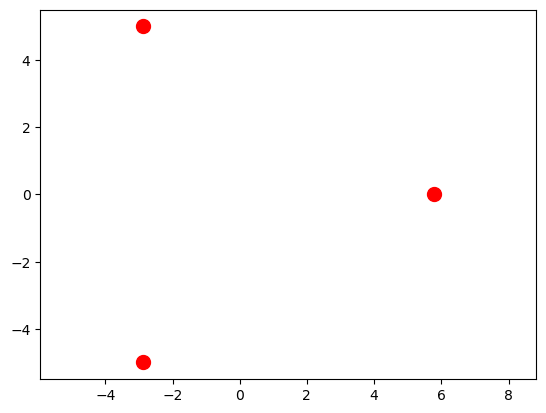

In [17]:
plt.plot(vertices[:,0], vertices[:,1], 'r.', markersize = 20)
plt.axis('equal');

### Этап 2. Представление одной стороны треугольника Рело

Вычислим значение введенных величин α и β


In [20]:
alpha = 2 * np.pi / n
beta = alpha / 2

Создадим массив значений угла для построения координат точек стороны
треугольника Рело

In [22]:
angel = np.linspace(-beta / 2, beta / 2, N)

Вычислим матрицу **side0** с координатами точек первой стороны треугольника Рело, используя параметрическое описание окружности с центром в точке **vertices[0]** радиусом **r** для значений угла на отрезке $[\pi - \frac{\beta}{2}, \pi + \frac{\beta}{2}]$.

In [24]:
side0 = vertices[0] + r * np.transpose([np.cos(angel + np.pi), 
                                        np.sin(angel + np.pi)])

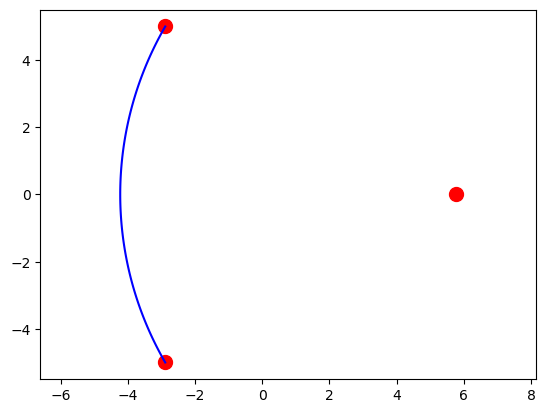

In [25]:
plt.plot(vertices[:,0], vertices[:,1], 'r.', markersize = 20)
plt.plot(side0[:,0], side0[:,1], 'b-', markersize = 20)
plt.axis('equal');

Вычислим матрицу **side1** с координатами точек, описывающих сторону треугольника Рело относительно второй вершины **vertices[1]**.

In [27]:
side1 = vertices[1] + r * np.transpose([np.cos(angel + np.pi + alpha), 
                                        np.sin(angel + np.pi + alpha)])

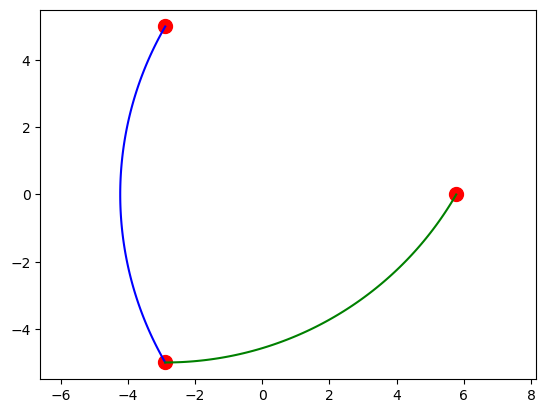

In [28]:
plt.plot(vertices[:,0], vertices[:,1], 'r.', markersize = 20)
plt.plot(side0[:,0], side0[:,1], 'b-', markersize = 20)
plt.plot(side1[:,0], side1[:,1], 'g-', markersize = 20)
plt.axis('equal');

### Этап 3. Моделирование границы треугольника Рело

Создадим СПИСОК из матриц, каждая их которых содержит координаты точек
одной из сторон треугольника Рело

In [31]:
listSides = [vertices[i] + r * np.transpose([np.cos(angel + np.pi + i * alpha),
                                           np.sin(angel + np.pi + i * alpha)])
            for i in range(n)]

С помощью фунции **concatenate** из расширения **numpy** объединим массивы, созданные для каждой из сторон треугольника Рело, в единый массив **sides**.

In [33]:
sides = np.concatenate(listSides)

Построим изображение вершин и всех сторон треугольника Рело

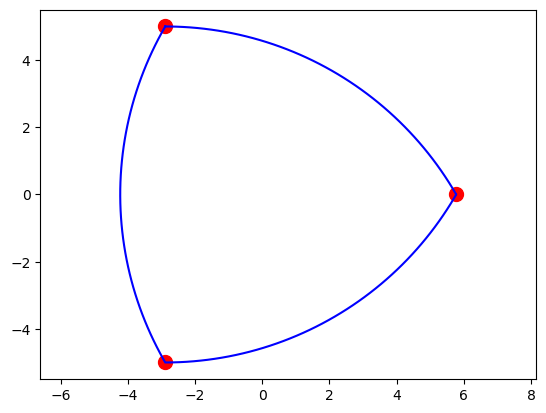

In [35]:
plt.plot(vertices[:,0], vertices[:,1], 'r.', markersize = 20)
plt.plot(sides[:,0], sides[:,1], 'b-', markersize = 20)
plt.axis('equal');

## Задание 4.2. Построение правильного многоугольника Рело

Рассмотрим треугольник $ABC$. Из определения правильного многоугольника Рело следует, что треугольник $ABC$ является равнобедренным.

Пусть правильный $n$-угольник ($n$ - нечётное число) является основой для построения правильного многоугольника Рело шириной $r$. Опишем вокруг него окружность радиуса $R$ и заметим, что каждая из его вершина равномерно распределена по ней.

Так как угол $\angle BAC$, который опирается на ту же дугу, что и центральный $\angle \theta$, то он будет равен его половине. То есть:
$$\angle BAC = \frac{\angle \theta}{2}$$
$\angle \theta = \frac{2 \pi}{n}$. Подставляя в формулу выше получим:
$$\angle BAC = \frac{2 \pi}{2n} = \frac{\pi}{n}$$

Следовательно, по свойству равнобедренного треугольника, $\angle HAC = \frac{\pi}{2n}$, где $AH$ - высота треугольника. Найдем через синус угла $\angle HBC$ сторону $a$:
$$\sin(\angle HAC) = \frac{a}{2r} \Rightarrow$$
$$a = 2r\sin(\angle HAC) = 2r\sin(\frac{\pi}{2n})$$

Рассмотрим равнобедренный треугольник $OAC$. В нем боковые стороны равны $R$, а основание равно $a$. Тогда, по теореме косинусов:

$$a^2 = R^2 + R^2 - 2 R R \cos(\angle AOC) \Rightarrow$$
$$a^2 = 2R^2(1 - \cos(\angle AOC)$$
Используя тригонометрическую формулу $1 - \cos(x) = 2 \sin(\frac{x}{2})$ получим:
$$a^2 = 2R^22 \sin(\frac{\angle AOC}{2}) \Rightarrow$$
$$a = 2R \sin(\frac{\angle AOC}{2})$$

Исходя того, что $\angle AOC$ — центральный угол, получим:
$$2r \sin(\frac{\pi}{2n}) = 2R \sin(\frac{2 \pi}{2n}) \Rightarrow$$
$$R = \frac{r \sin(\frac{\pi}{2n})}{\sin(\frac{\pi}{n})}$$


Определяем переменные (количество вершин, количество точек,координаты центра, ширину)

In [39]:
nOfVert, nOfPoints = 5, 100
center = np.array([0, 0])
r = 10.

Ищем радиус окружности

In [41]:
R = r * np.sin(np.pi / (2 * nOfVert)) / np.sin(np.pi / nOfVert)

Создаем массив вершин многоугольника

In [43]:
tArray = np.arange(0, 2 * np.pi, 2 * np.pi / nOfVert)
verts = np.transpose([center[0] + R * np.cos(tArray),center[1] + R * np.sin(tArray)])

Создаем массив точек для построения стороны многоугольника Рело

In [45]:
alpha = 2 * np.pi / nOfVert
beta = alpha / 2
angles = np.linspace(-beta / 2, beta / 2, nOfPoints)
sides = np.concatenate([verts[step] + r * np.transpose([np.cos(angles + np.pi + step * alpha),np.sin(angles + np.pi + step * alpha)]) for step in range(nOfVert)])

Тест:

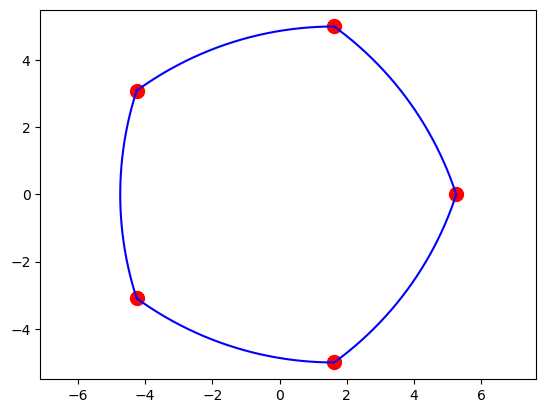

In [47]:
plt.plot(verts[:,0], verts[:,1], 'r.', markersize = 20)
plt.plot(sides[:,0], sides[:,1], 'b-', markersize = 20)
plt.axis('equal');

### Задание 4.3. Результирующая пользовательская функция

Напишите пользовательскую функцию **regularPolygonRelo(n, center, r, N)** на основании кода из **Задания 4.2**. Функция должна возвращать матрицу, каждая строка которой содержит координаты точек, описывающих границу правильного многоугольника Рело.


In [50]:
def regularPolygonReloFunc(n: int = 3, center: np.ndarray = np.array([0, 0]),
    r: float = 1., 
    N: int = 100) -> np.ndarray:

    """
    Покоординатно описывает границы многоугольника Рело.

    Параметры:
    n:      Количество вершин (по умолчанию 3);
    center: Координаты центра многоугольника (по умолчанию np.array([0, 0]));
    r:      Радиус дуг, образующих границу (по умолчанию 1);
    N:      Количество точек на каждой дуге (по умолчанию 100).

    Возвращает:
    Матрицу координат точек, описывающих границу
    правильного многоугольника Рело. Первый столбец — координаты по х, второй — по у.        
    """
    
    assert n >= 3, "n must be more than 2."
    assert n % 2 != 0, "n must be an odd number."
    assert r > 0, "r must be more than 0."
    assert isinstance(N, int), "N must be an integer."
    assert isinstance(center, np.ndarray), "center must have the np.ndarray data type."
    
    R = r * np.sin(np.pi / (2 * n)) / np.sin(np.pi / n)
    tArray = np.arange(0, 2 * np.pi, 2 * np.pi / n)
    verts = np.transpose([center[0] + R * np.cos(tArray),center[1] + R * np.sin(tArray)])

    alpha = 2 * np.pi / n
    beta = alpha / 2
    angles = np.linspace(-beta / 2, beta / 2, N)
    sides = np.concatenate([verts[step] + r * np.transpose([np.cos(angles + np.pi + step * alpha), np.sin(angles + np.pi + step * alpha)]) for step in range(n)])
    return sides

In [51]:
regularPolygonReloFunc.__annotations__

{'n': int,
 'center': numpy.ndarray,
 'r': float,
 'N': int,
 'return': numpy.ndarray}

Создадим модуль **relo.py**, в котором будет содержаться пользовательская функция **regularPolygonRelo**:

In [53]:
import relo
from relo import regularPolygonReloFunc
regularPolygonReloFunc();

ModuleNotFoundError: No module named 'relo'

## Задание 4.4. Тестирование функции

In [ ]:
regularPolygonReloFunc(1, np.array([1, 2]), 3, 10)

In [ ]:
regularPolygonReloFunc(3, np.array([1, 2]), -10, 10)

In [ ]:
regularPolygonReloFunc(3, np.array([1, 2]), 3, 10.)

In [ ]:
regularPolygonReloFunc(3, (1, 2), 10, 100)

Построим в одной системе координат правильные многоугольники Рело. При этом вызывая пользовательскую функцию regularPolygonRelo используя различные способы указания аргументов:
1) Все аргументы позиционные;
2) Все аргументы ключевые;
3) Аргументы позиционные и ключевые;
4) Все аргументы определяются стандартными значениями

In [ ]:
#Все аргументы позиционные;
tempMatrix = regularPolygonReloFunc(5, np.array([-0.5, 1]), 4, 20)
plt.plot(tempMatrix[:,0], tempMatrix[:,1], 'r-', markersize = 20)

#Все аргументы ключевые;
tempMatrix = regularPolygonReloFunc(N = 222, n = 7, center = np.array([4, -4]), r = 6)
plt.plot(tempMatrix[:,0], tempMatrix[:,1], 'g:', markersize = 20)

#Аргументы позиционные и ключевые;
tempMatrix = regularPolygonReloFunc(5, center = np.array([7, 4]), N = 112, r = 4)
plt.plot(tempMatrix[:,0], tempMatrix[:,1], 'b', markersize = 20)

#Все аргументы определяются стандартными значениями;
tempMatrix = regularPolygonReloFunc()
plt.plot(tempMatrix[:,0], tempMatrix[:,1], 'g--', markersize = 20)

plt.axis('equal');